# 第 12 章 · 小图像 Diffusion 经典缩影

用 sklearn digits 的 8×8 手写数字展示 DDPM 的前向加噪、反向去噪和采样轨迹。

配套交互演示：[章节网页](../ch12.html)

## 本节目标

- 真实小图像案例
- DDPM 加噪公式
- 从噪声逐步回到数字形状
- 对比 toy 与经典图像生成

## 1. 为什么要换成小图像

1D toy 适合讲公式，但读者很难把它和「生成图像」联系起来。这里用经典 `sklearn.datasets.load_digits`：每张图只有 8×8，足够快，也能看清数字结构如何被噪声破坏。

这个 notebook 不训练大模型；它用同类数字的平均图像作为教学版 denoiser，展示 diffusion 的过程缩影。

## 2. 前向扩散：清晰数字如何变成噪声

**DDPM forward**

```text
x_t = sqrt(alpha_bar_t) * x0 + sqrt(1-alpha_bar_t) * epsilon
```

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "labs").exists() and (ROOT.parent / "labs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch12"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
from create import *

In [2]:
digits_diffusion_table()

,t,beta_t,signal_scale sqrt(alpha_bar),noise_scale sqrt(1-alpha_bar)
0,1,0.060,0.970,0.245
1,2,0.096,0.922,0.388
2,3,0.132,0.859,0.512
3,4,0.168,0.783,0.622
4,5,0.204,0.699,0.715
5,6,0.240,0.609,0.793


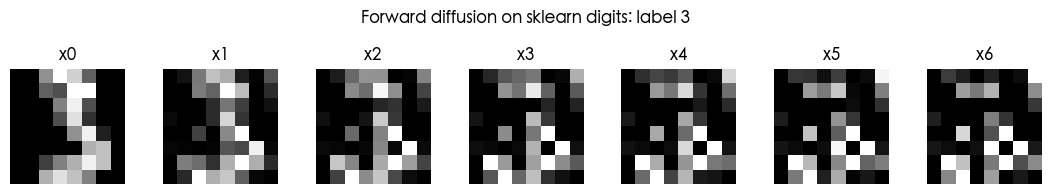

In [3]:
plot_digits_forward(seed=7, digit=3)

**思考** · t 越大，signal_scale 和 noise_scale 如何变化？

<details><summary>查看答案</summary>

signal_scale 下降，noise_scale 上升，图像越来越像噪声。

</details>

## 3. 反向去噪：模型到底学什么

真实 diffusion 模型会学习预测噪声或 score。这里用「同类数字原型」模拟一个已经学到数字结构的 denoiser：每一步都把噪声图往数字原型拉近一点。

这不是生产模型，但能清楚展示为什么 reverse process 是一串小步修复，而不是一次性画图。

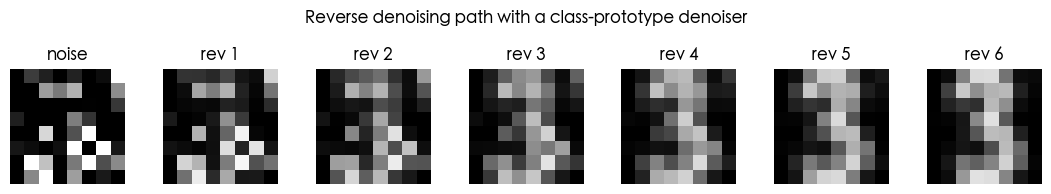

In [4]:
plot_digits_reverse(seed=7, digit=3)

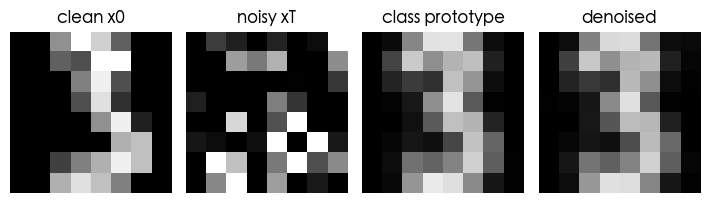

In [5]:
plot_digits_denoiser_comparison(seed=7, digit=3)

In [6]:
digits_diffusion_summary(seed=7, digit=3)

digit label: 3
MSE(noisy, clean)   = 0.1824
MSE(denoised, clean)= 0.0247
这个 notebook 用类原型代替真实神经网络，目的是展示经典图像 diffusion 的过程缩影。


**思考** · denoised 的 MSE 是否应低于 noisy？

<details><summary>查看答案</summary>

应低于 noisy，说明去噪轨迹把图像拉回了数据分布附近。

</details>

## 4. 和真实 DDPM 的边界

**相同点**：都有前向加噪、按时间步逐步反推、从纯噪声回到数据分布。

**不同点**：真实 DDPM 的 denoiser 是神经网络，这里用类原型代替，只用于理解过程。

## 小结

经典图像 diffusion 的核心不是魔法生成，而是学习每个噪声强度下如何做一小步去噪。对照 [ch12.html](../ch12.html)。

## 练习

1. 把 digit=3 改成 digit=8，反向轨迹有什么差别？
2. 如果 denoiser 用错类别原型，会发生什么？